In [46]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
cwd = Path.cwd()
project_root = cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("Done!")

In [3]:
from credit_risk.dataset import AFTER_EDA, load_splits

2026-06-04 17:02:08.303 | INFO     | credit_risk.config:<module>:11 - PROJ_ROOT path is: /Users/ak007/SML/Credit-Risk-Default-Prediction-System


In [4]:
train_df, val_df, test_df, metadata = load_splits(path=AFTER_EDA)

2026-06-04 17:02:08.521 | INFO     | credit_risk.dataset:load_splits:263 - Checking if the files exists...
2026-06-04 17:02:08.528 | INFO     | credit_risk.dataset:load_splits:265 - Loading the Cached files...
2026-06-04 17:02:08.724 | INFO     | credit_risk.dataset:load_splits:273 - Loaded sucessfully all the splits and the metadata, Train_df shape: (466071, 110), val_df shape: (420204, 110), test_df shape: (431712, 110)


In [5]:
train_df.shape, val_df.shape, test_df.shape

((466071, 110), (420204, 110), (431712, 110))

In [6]:
# let's first check the null percentages in the columns
train_null = train_df.isna().mean(axis=0).sort_values(ascending=False)*100

In [7]:
train_null.head(40)

inq_fi                                 100.000000
sec_app_fico_range_low                 100.000000
annual_inc_joint                       100.000000
dti_joint                              100.000000
verification_status_joint              100.000000
open_acc_6m                            100.000000
open_il_12m                            100.000000
open_il_24m                            100.000000
mths_since_rcnt_il                     100.000000
total_bal_il                           100.000000
il_util                                100.000000
open_rv_12m                            100.000000
open_rv_24m                            100.000000
max_bal_bc                             100.000000
all_util                               100.000000
total_cu_tl                            100.000000
inq_last_12m                           100.000000
revol_bal_joint                        100.000000
open_act_il                            100.000000
sec_app_fico_range_high                100.000000


In [8]:
all_null = list(train_null[train_null == 100.0].index)

In [9]:
len(all_null)

30

In [10]:
all_null

['inq_fi',
 'sec_app_fico_range_low',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'open_acc_6m',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_cu_tl',
 'inq_last_12m',
 'revol_bal_joint',
 'open_act_il',
 'sec_app_fico_range_high',
 'sec_app_inq_last_6mths',
 'sec_app_mths_since_last_major_derog',
 'sec_app_chargeoff_within_12_mths',
 'sec_app_num_rev_accts',
 'sec_app_open_act_il',
 'sec_app_revol_util',
 'sec_app_open_acc',
 'sec_app_mort_acc',
 'sec_app_collections_12_mths_ex_med',
 'sec_app_earliest_cr_line']

In [11]:
train_df.drop(columns=all_null, inplace=True)
val_df.drop(columns=all_null, inplace=True)
test_df.drop(columns=all_null, inplace=True)

In [13]:
y_train = train_df['target']
y_val = val_df['target']
y_test = test_df['target']

In [14]:
X_train = train_df.drop(columns=["target"])
X_val = val_df.drop(columns=["target"])
X_test = test_df.drop(columns=["target"])

In [15]:
assert (X_train.shape[1] == X_val.shape[1]) and (X_val.shape[1] == X_test.shape[1])

In [16]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 466071 entries, 1117060 to 1939378
Data columns (total 79 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   loan_amnt                       466071 non-null  float64       
 1   funded_amnt                     466071 non-null  float64       
 2   funded_amnt_inv                 466071 non-null  float64       
 3   term                            466071 non-null  str           
 4   int_rate                        466071 non-null  float64       
 5   installment                     466071 non-null  float64       
 6   grade                           466071 non-null  str           
 7   sub_grade                       466071 non-null  str           
 8   emp_title                       438488 non-null  str           
 9   emp_length                      445069 non-null  str           
 10  home_ownership                  466071 non-null  str           
 

In [17]:
X_train.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,issue_d,dti,delinq_2yrs,fico_range_low,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
count,466071.000000,466071.000000,466071.00000,466071.000000,466071.000000,4.660670e+05,466071,466071.000000,466042.000000,466071.000000,...,395795.000000,395795.000000,395642.000000,411955.000000,464706.000000,465966.000000,3.957950e+05,4.160410e+05,4.160410e+05,3.957950e+05
mean,14313.301461,14287.813230,14218.32476,13.826272,431.987386,7.326826e+04,2013-08-23 11:04:39.946188,17.217138,0.284599,696.118510,...,0.082108,1.918150,94.709580,51.974091,0.106663,0.033844,1.683230e+05,4.598811e+04,2.012186e+04,3.764764e+04
min,500.000000,500.000000,0.00000,5.420000,4.930000,1.896000e+03,2007-06-01 00:00:00,0.000000,0.000000,610.000000,...,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8000.000000,8000.000000,8000.00000,10.990000,256.610000,4.500000e+04,2013-03-01 00:00:00,11.360000,0.000000,675.000000,...,0.000000,1.000000,92.000000,25.000000,0.000000,0.000000,4.652800e+04,1.989000e+04,7.400000e+03,1.205350e+04
50%,12000.000000,12000.000000,12000.00000,13.660000,379.760000,6.300000e+04,2014-01-01 00:00:00,16.870000,0.000000,690.000000,...,0.000000,2.000000,100.000000,50.000000,0.000000,0.000000,1.103890e+05,3.497900e+04,1.420000e+04,2.824900e+04
75%,20000.000000,20000.000000,19950.00000,16.490000,566.500000,8.886150e+04,2014-07-01 00:00:00,22.780000,0.000000,710.000000,...,0.000000,3.000000,100.000000,80.000000,0.000000,0.000000,2.459310e+05,5.770300e+04,2.630000e+04,5.091350e+04
max,35000.000000,35000.000000,35000.00000,26.060000,1409.990000,7.500000e+06,2014-12-01 00:00:00,39.990000,29.000000,845.000000,...,24.000000,26.000000,100.000000,100.000000,12.000000,63.000000,9.999999e+06,2.688920e+06,1.090700e+06,1.241783e+06
std,8285.328704,8273.171262,8296.41226,4.357272,243.491216,5.496616e+04,NaN,7.850806,0.797234,30.773018,...,0.445473,1.573425,8.066187,34.611561,0.332642,0.329736,1.701041e+05,4.362475e+04,1.964710e+04,3.973245e+04


In [18]:
# there is one more columns that should be converted in datetime
X_train['earliest_cr_line'] = pd.to_datetime(X_train['earliest_cr_line'], format="%b-%Y")

In [19]:
# we will drop policy_code cause it doesn't have any signal/variance that model can learn from
X_train.drop(columns='policy_code', inplace=True)

In [20]:
numeric_cols = X_train.select_dtypes(include='number').columns
numeric_cols

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate',
       'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low',
       'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths',
       'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths',
       'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
       'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
       'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
       'mths_since_recent_inq', 'mths_since_recent_revol_delinq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'n

In [21]:
string_cols = X_train.select_dtypes(include='str').columns
string_cols

Index(['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'desc', 'purpose', 'title',
       'zip_code', 'addr_state', 'initial_list_status', 'application_type',
       'disbursement_method'],
      dtype='str')

In [22]:
datetime_cols = X_train.select_dtypes(include=['datetime']).columns
datetime_cols

Index(['issue_d', 'earliest_cr_line'], dtype='str')

In [23]:
assert len(numeric_cols) + len(string_cols) + len(datetime_cols) == len(X_train.columns)

In [25]:
string_cols

Index(['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'desc', 'purpose', 'title',
       'zip_code', 'addr_state', 'initial_list_status', 'application_type',
       'disbursement_method'],
      dtype='str')

In [28]:
# creating some derived features
# credit age years = issue_d - earliest_cr_line
train_null[["issue_d", 'earliest_cr_line']]

issue_d             0.000000
earliest_cr_line    0.006222
dtype: float64

In [35]:
credit_age = (X_train['issue_d'] - X_train['earliest_cr_line']).dt.days / 365.25
credit_age

1117060    25.248460
1117061    20.334018
1117062    22.080767
1117063    12.334018
1117064    14.165640
             ...    
1939374    23.249829
1939375     8.000000
1939376    11.331964
1939377    10.417522
1939378     8.914442
Length: 466071, dtype: float64

In [36]:
X_train['credit_age_yrs'] = credit_age

In [37]:
# fico_mid = average of fico_low and fico_high
X_train[['fico_range_low', 'fico_range_high']].notna().all()

fico_range_low     True
fico_range_high    True
dtype: bool

In [39]:
fico_mid = (X_train['fico_range_low'] + X_train['fico_range_high'])/2
fico_mid

1117060    712.0
1117061    752.0
1117062    682.0
1117063    687.0
1117064    667.0
           ...  
1939374    702.0
1939375    682.0
1939376    722.0
1939377    677.0
1939378    717.0
Length: 466071, dtype: float64

In [40]:
X_train['fico_mid'] = fico_mid

In [42]:
len(numeric_cols)

61

In [53]:
outlier_suspects = ["annual_inc", "revol_bal", "dti", "delinq_2yrs", "pub_rec", 'tax_liens', 'collections_12_mths_ex_med', 'chargeoff_within_12_mths', 'acc_now_delinq', 'delinq_amnt', 'tot_coll_amt', 'tot_cur_bal']

In [55]:
len(outlier_suspects)

12

<Axes: >

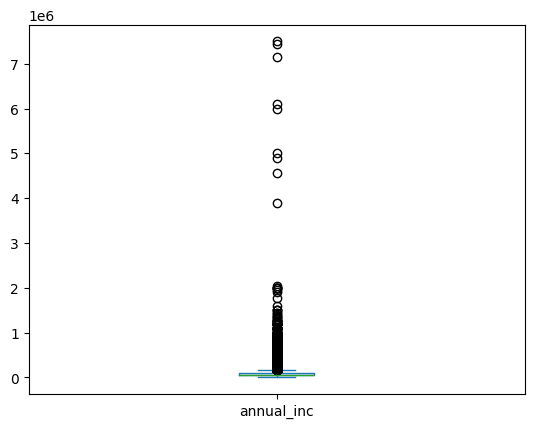

In [57]:
X_train['annual_inc'].plot.box()

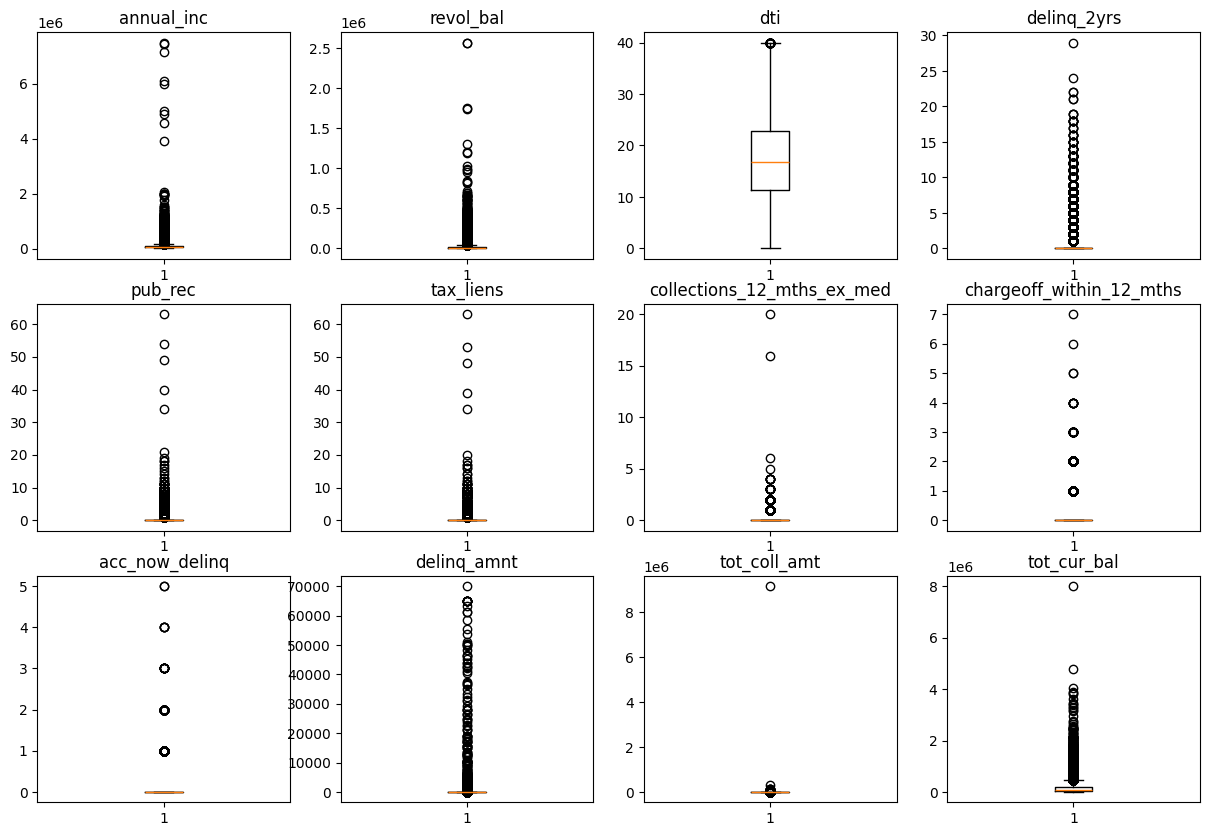

In [58]:
fig, ax = plt.subplots(ncols=4, nrows=3, figsize=(15, 10))
for idx, col in enumerate(outlier_suspects[:12]):
    i, j = divmod(idx, 4)
    ax[i][j].boxplot(X_train[col].dropna())
    ax[i][j].set_title(col)
plt.show()